# Modelo preliminar para el diagnóstico del Parkinson mediante análisis de señales inerciales de la prueba Timed Up and Go

YEISON PILLIMUE

Contexto del problema

La enfermedad de Parkinson es un trastorno neurodegenerativo progresivo que afecta principalmente el sistema motor, produciendo síntomas como rigidez muscular, temblor, lentitud de movimiento y alteraciones en la marcha. Debido a que su diagnóstico depende en gran medida de la evaluación clínica por especialistas, en muchos casos la detección ocurre cuando la enfermedad ya se encuentra en etapas avanzadas.

En contextos donde el acceso a neurólogos es limitado o donde los tiempos de espera para consulta especializada pueden ser prolongados, resulta valioso contar con herramientas que permitan identificar tempranamente posibles casos sospechosos para priorizar su evaluación clínica.

Una de las pruebas más utilizadas para evaluar alteraciones en la marcha es el Timed Up and Go (TUG), que mide el desempeño de una persona al levantarse de una silla, caminar una distancia corta, girar y regresar al punto inicial. Cuando esta prueba se instrumenta con sensores o sistemas de medición de movimiento, es posible obtener variables cuantitativas relacionadas con la dinámica de la marcha, como velocidad, amplitud de zancada o movimiento de los brazos.

Estas variables pueden contener patrones característicos asociados a alteraciones motoras presentes en pacientes con Parkinson.

Objetivo del proyecto

El objetivo de este proyecto es explorar el uso de técnicas de analítica de datos y aprendizaje automático para identificar patrones en variables derivadas del test TUG que permitan diferenciar entre pacientes con enfermedad de Parkinson y sujetos control.

En particular, se busca evaluar si un modelo predictivo puede utilizar estas características de la marcha como base para apoyar procesos de diagnónstico, contribuyendo potencialmente a reducir retrasos en la evaluación especializada.

Nota sobre las limitaciones del dataset

Es importante mencionar que el dataset utilizado es relativamente pequeño, lo cual puede influir en la estabilidad de los modelos entrenados. Por esta razón, los resultados obtenidos deben interpretarse como exploratorios, y se recomienda validar el modelo en conjuntos de datos más grandes antes de considerar su uso en un contexto clínico real.

In [32]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


Importacion de librerias

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import (
    SMOTE,
    RandomOverSampler
)

Cargue del dataset

In [4]:
Tabla1 = r"C:\Users\pilli\OneDrive\Escritorio\UNIVERSIDAD\PDG II\Table 1.xlsx"
df = pd.read_excel(Tabla1) 

In [5]:
df.head()

,ID,Estado,Mean stride amplitude (cm),SD stride amplitude (cm),Mean stride speed (cm/s),SD stride speed,Mean speed correlation,Mean height of foot lift (cm),SD height of foot lift (cm),Arm swing indicator,Gait evaluation MDS-UPDRS,Target
0,1 R,Paciente,127,4,111,2,0.96,9.30,1.43,0.82,0,1
1,2 R,Paciente,83,12,85,13,0.77,9.16,0.55,0.82,1,1
2,3 L,Paciente,75,6,75,11,0.88,8.66,0.65,0.82,1,1
3,4 R,Paciente,83,7,90,7,0.96,7.14,0.51,0.38,1,1
4,5 L,Paciente,75,8,81,10,0.97,6.82,0.88,0.38,1,1


In [6]:
# Visualiza las primeras filas
print(df.shape)
print(df.columns)

(42, 12)
Index(['ID', 'Estado', 'Mean stride amplitude (cm)',
       'SD stride amplitude (cm)', 'Mean stride speed (cm/s)',
       'SD stride speed', 'Mean speed correlation',
       'Mean height of foot lift (cm)', 'SD height of foot lift (cm)',
       'Arm swing indicator', 'Gait evaluation MDS-UPDRS', 'Target'],
      dtype='object')


In [7]:
# Tipos y nulos
print(df.info())
print(df.isnull().sum())

# Duplicados
print("Duplicados:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             42 non-null     object 
 1   Estado                         42 non-null     object 
 2   Mean stride amplitude (cm)     42 non-null     int64  
 3   SD stride amplitude (cm)       42 non-null     int64  
 4   Mean stride speed (cm/s)       42 non-null     int64  
 5   SD stride speed                42 non-null     int64  
 6   Mean speed correlation         42 non-null     float64
 7   Mean height of foot lift (cm)  42 non-null     float64
 8   SD height of foot lift (cm)    42 non-null     float64
 9   Arm swing indicator            42 non-null     float64
 10  Gait evaluation MDS-UPDRS      42 non-null     int64  
 11  Target                         42 non-null     int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 4.1

No se presentan valores nulos

In [8]:
# Revisión de la columna `Gait evaluation MDS-UPDRS` vs `Target`
tab = pd.crosstab(df['Gait evaluation MDS-UPDRS'], df['Target'])
print("Cross-tab Gait eval vs Target:\n", tab)

Cross-tab Gait eval vs Target:
 Target                     0   1
Gait evaluation MDS-UPDRS       
0                          8   9
1                          0  22
2                          0   3


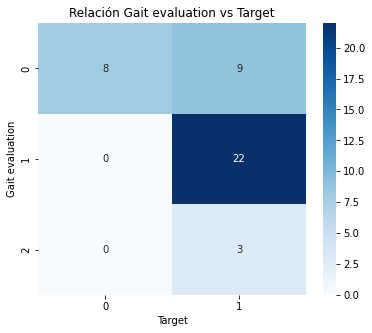

In [9]:
# Crear la tabla manualmente si ya la tienes
ct = pd.DataFrame({
    0: [8, 0, 0],
    1: [9, 22, 3]
}, index=[0,1,2])

ct.index.name = "Gait evaluation"
ct.columns.name = "Target"

plt.figure(figsize=(6,5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title("Relación Gait evaluation vs Target")
plt.show()

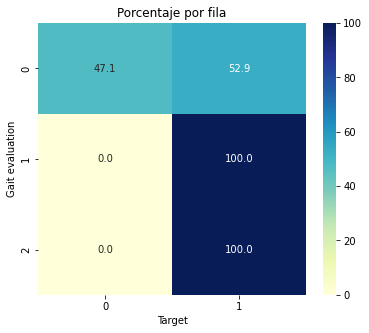

In [10]:
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

plt.figure(figsize=(6,5))
sns.heatmap(ct_percent, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title("Porcentaje por fila")
plt.show()

La MDS-UPDRS (Movement Disorder Society – Unified Parkinson’s Disease Rating Scale) es una escala clínica utilizada para evaluar la severidad de los síntomas en pacientes con enfermedad de Parkinson.

En este dataset, los participantes están clasificados según su condición clínica:

0: sujeto control (persona sana)

1, 2 y 3: pacientes con Parkinson en distintos niveles de severidad según la escala clínica

Para algunos análisis del proyecto, estas categorías se simplifican en una clasificación binaria:

0 → Control (sano)

1 → Paciente con Parkinson

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Crear variable binaria desde Gait
df['Gait_binary'] = np.where(df['Gait evaluation MDS-UPDRS'] > 0, 1, 0)

cm = confusion_matrix(df['Target'], df['Gait_binary'])
print(cm)

print(classification_report(df['Target'], df['Gait_binary']))

[[ 8  0]
 [ 9 25]]
              precision    recall  f1-score   support

           0       0.47      1.00      0.64         8
           1       1.00      0.74      0.85        34

    accuracy                           0.79        42
   macro avg       0.74      0.87      0.74        42
weighted avg       0.90      0.79      0.81        42



La matriz de confusión muestra que se clasificó correctamente todos los sujetos control (8/8), sin falsos positivos. Sin embargo, 9 pacientes con Parkinson fueron clasificados incorrectamente como controles, lo que indica que el diagnóstico aún presenta algunos falsos negativos.

El diagnóstico visual alcanza una exactitud global del 79%.
La precisión para la clase de pacientes es del 100%, lo que significa que cuando se clasifica un paciente con Parkinson, la clasificación es correcta. No obstante, el recall del 74% indica que aún hay pacientes que no son detectados.

Se utiliza un countplot de seaborn para visualizar la distribución de la variable objetivo (Target).
Esta gráfica permite observar cuántos registros corresponden a cada clase del dataset:
0 = sujetos control (personas sanas)
1 = pacientes con Parkinson.

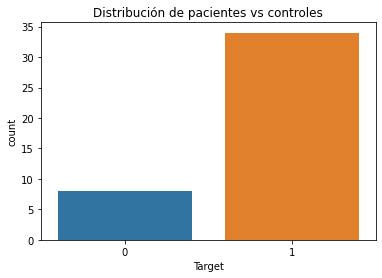

In [12]:
sns.countplot(x="Target", data=df)
plt.title("Distribución de pacientes vs controles")
plt.show()


En la gráfica se observa un desbalance de clases en el dataset.
La mayoría de los registros corresponden a pacientes con Parkinson (clase 1),mientras que los sujetos control (clase 0) representan una proporción menor.
Este desbalance puede afectar el entrenamiento de los modelos de machine learning, ya que los algoritmos podrían favorecer la clase mayoritaria. Por esta razón, más adelante se evaluarán estrategias de balanceo como SMOTE o Random Oversampling.

In [13]:
# Detectar inconsistencias (ejemplo: gait eval = 0 pero Target=1)
inconsist = df[(df['Gait evaluation MDS-UPDRS'] == 0) & (df['Target'] == 1)]
print("Inconsistencias (Gait=0 pero Target=1):", len(inconsist))
# Si hay filas, muéstralas para revisión clínica
inconsist

Inconsistencias (Gait=0 pero Target=1): 9


,ID,Estado,Mean stride amplitude (cm),SD stride amplitude (cm),Mean stride speed (cm/s),SD stride speed,Mean speed correlation,Mean height of foot lift (cm),SD height of foot lift (cm),Arm swing indicator,Gait evaluation MDS-UPDRS,Target,Gait_binary
0,1 R,Paciente,127,4,111,2,0.96,9.30,1.43,0.82,0,1,0
12,13 R,Paciente,115,8,105,6,0.93,9.83,0.40,1.18,0,1,0
13,14 L,Paciente,117,7,101,13,0.95,8.78,0.91,1.18,0,1,0
16,17 R,Paciente,108,10,84,8,0.97,8.05,1.56,2.24,0,1,0
17,18 L,Paciente,101,5,79,4,0.96,8.01,0.40,2.24,0,1,0
18,19 R,Paciente,110,11,102,18,0.95,6.33,1.38,2.29,0,1,0
19,20 L,Paciente,114,14,103,13,0.95,6.24,1.17,2.29,0,1,0
26,27 R,Paciente,123,16,115,18,0.96,12.04,1.93,1.86,0,1,0
27,28 L,Paciente,130,8,122,12,0.94,12.59,1.34,1.86,0,1,0


In [14]:
# ---------- 3) Estadísticas descriptivas ----------
num_cols = [c for c in df.columns if df[c].dtype in [np.float64, np.int64] and c not in ['ID','Target','Gait evaluation MDS-UPDRS','Gait_binary']]
print(df[num_cols].describe().T)

                               count        mean        std    min      25%  \
Mean stride amplitude (cm)      42.0  101.952381  27.554781  21.00  93.2500   
SD stride amplitude (cm)        42.0    8.666667   3.620178   3.00   6.2500   
Mean stride speed (cm/s)        42.0   91.595238  26.159044  20.00  81.2500   
SD stride speed                 42.0   10.071429   4.805448   2.00   6.2500   
Mean speed correlation          42.0    0.914762   0.085831   0.51   0.9025   
Mean height of foot lift (cm)   42.0    8.491190   2.268237   3.48   6.8850   
SD height of foot lift (cm)     42.0    0.931429   0.403289   0.29   0.5875   
Arm swing indicator             42.0    1.203095   0.692917   0.38   0.6200   

                                   50%       75%     max  
Mean stride amplitude (cm)     109.500  117.7500  142.00  
SD stride amplitude (cm)         8.000   11.7500   18.00  
Mean stride speed (cm/s)        96.000  111.0000  129.00  
SD stride speed                 10.000   13.0000   1

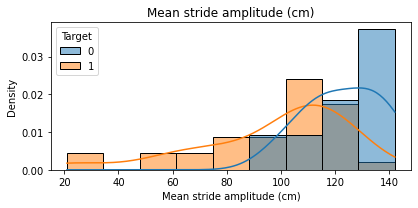

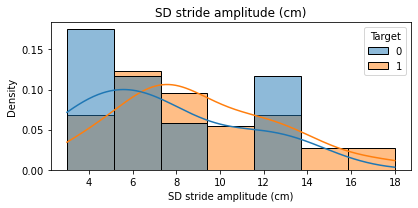

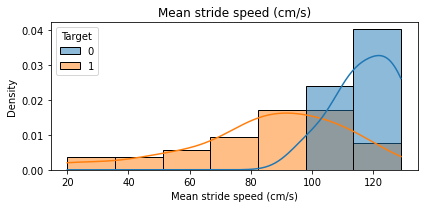

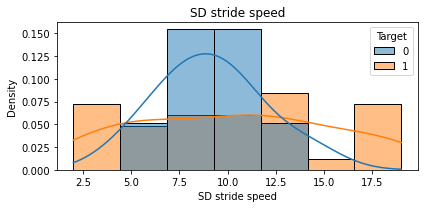

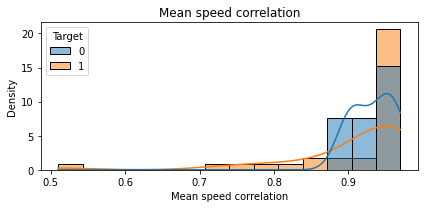

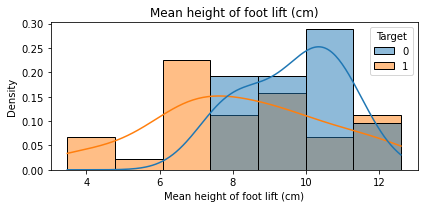

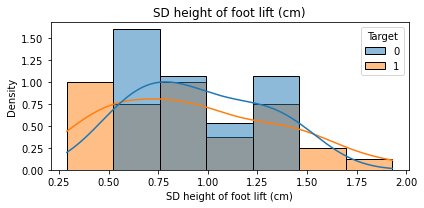

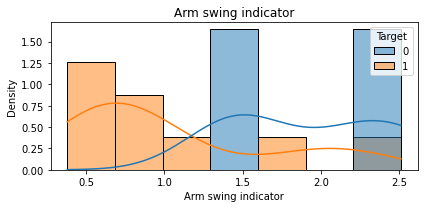

In [15]:
cols_to_plot = [col for col in num_cols if col != 'Gait evaluation MDS-UPDRS']

for col in cols_to_plot:
    plt.figure(figsize=(6,3))
    sns.histplot(data=df, x=col, hue='Target',
                 kde=True, stat="density", common_norm=False)
    plt.title(col)
    plt.tight_layout()
    plt.show()

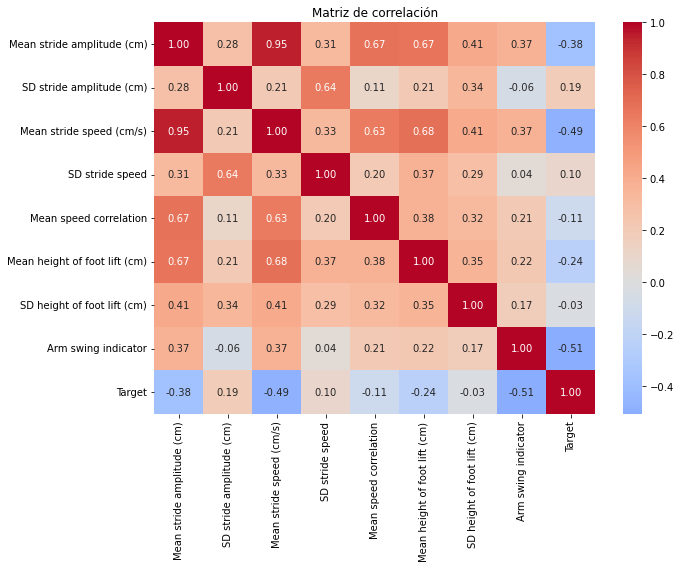

In [16]:
# ---------- 4) Correlación ----------
corr = df[num_cols + ['Target']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Matriz de correlación")
plt.tight_layout()

In [17]:
# Inspección de correlaciones altas (>0.85)
high_corr = []
for i, c1 in enumerate(num_cols):
    for c2 in num_cols[i+1:]:
        if abs(df[c1].corr(df[c2])) > 0.70:
            high_corr.append((c1,c2, df[c1].corr(df[c2])))
print("Pares con alta correlación (>0.85):", high_corr)

Pares con alta correlación (>0.85): [('Mean stride amplitude (cm)', 'Mean stride speed (cm/s)', 0.9453225874086371)]


Se detectó una alta correlación (>0.85) entre:
Mean stride amplitude (cm) y Mean stride speed (cm/s). Esto indica que ambas variables contienen información muy similar sobre la dinámica de la marcha. A medida que aumenta la amplitud del paso, también aumenta la velocidad del mismo.

En términos de modelado, esta relación sugiere posible redundancia entre variables. Sin embargo, dado el tamaño reducido del dataset y la naturaleza clínica de las mediciones, ambas variables se mantienen para preservar información potencialmente relevante para la clasificación.

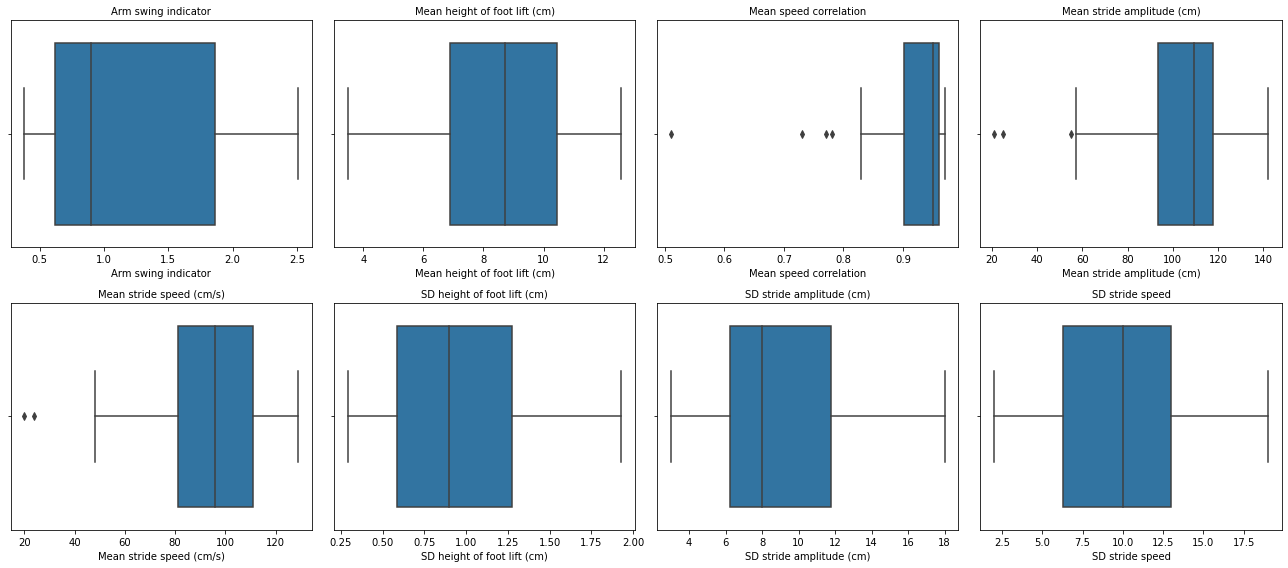

In [18]:
# Lista de variables numéricas (excluyendo ID y target si aplica)
numeric_cols = df.select_dtypes(include=['number']).columns.difference(['ID','Target','Gait evaluation MDS-UPDRS','Gait_binary'])

# Número de columnas
num_cols = len(numeric_cols)

# Configuración de la grilla
ncols = 4  # más legible que 5
nrows = (num_cols // ncols) + (1 if num_cols % ncols > 0 else 0)

# Crear figura
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4*nrows))
axes = axes.flatten()

# Boxplot por variable
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

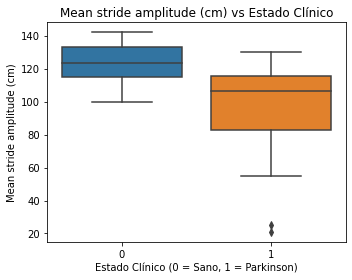

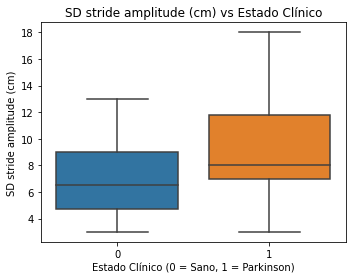

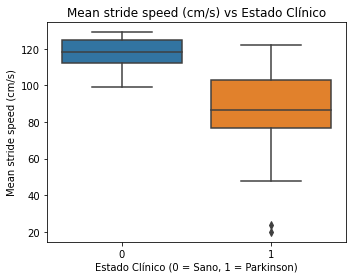

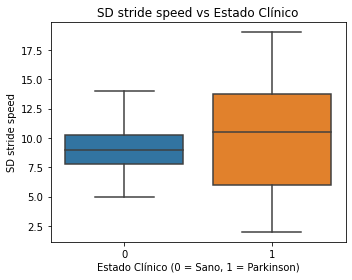

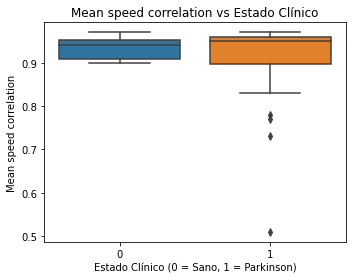

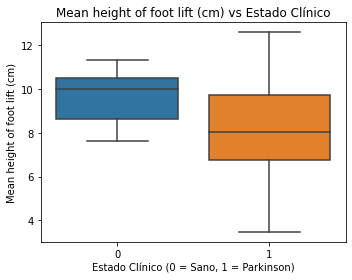

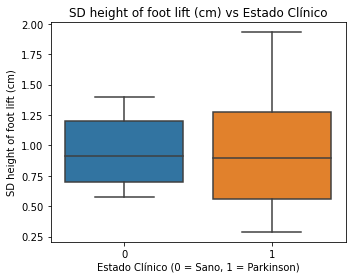

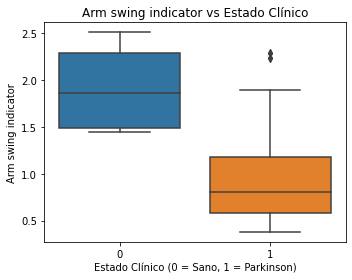

In [19]:
# Variables predictoras (sin ID ni target)
features = [col for col in df.columns if col not in ['ID', 'Target', 'Estado','Gait evaluation MDS-UPDRS','Gait_binary']]

for col in features:
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df, x='Target', y=col)
    plt.title(f'{col} vs Estado Clínico')
    plt.xlabel('Estado Clínico (0 = Sano, 1 = Parkinson)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Se comparan dos variables de marcha entre sujetos sanos (0) y pacientes con Parkinson (1).

Mean stride speed (cm/s):
    Los sujetos sanos presentan velocidades de paso más altas y con menor variabilidad.En contraste, los pacientes con Parkinson muestran velocidades promedio menores y una mayor dispersión, lo cual es consistente con las alteraciones motoras características de la enfermedad.

Arm swing indicator:
    Los sujetos sanos presentan valores más altos en el indicador de balanceo de brazos, mientras que los pacientes con Parkinson muestran valores significativamente menores. Esto refleja la reducción del movimiento de los brazos durante la marcha, uno de los síntomas motores comunes en Parkinson.

# MODELADO

Para el modelado predictivo se evaluaron tres algoritmos de clasificación: Random Forest, AdaBoost y XGBoost.

Debido al desbalance de clases en el conjunto de entrenamiento (27 pacientes vs 6 controles), se aplicó la técnica SMOTE para generar muestras sintéticas de la clase minoritaria durante la validación cruzada.

Los modelos se evaluaron utilizando validación cruzada estratificada y métricas como accuracy, precision, recall, F1-score y ROC-AUC. El criterio principal de selección fue el recall, ya que en un contexto clínico es más importante reducir los falsos negativos (pacientes no detectados).

Distribución en TRAIN (total):
{1: 27, 0: 6}
Etiqueta minoritaria: 0 (n=6)

Minority samples in each training fold: [5, 5, 4, 5, 5]
Min minority samples in any training fold: 4
Usaremos SMOTE con k_neighbors = 3

Ejecutando CV para: RandomForest ...

Ejecutando CV para: AdaBoost ...

Ejecutando CV para: XGBoost ...

Resultados CV (promedios):
              accuracy  precision    recall        f1   roc_auc
RandomForest  0.938095   0.966667  0.960000  0.959596  0.960000
AdaBoost      0.880952   0.933333  0.926667  0.926263  0.863333
XGBoost       0.785714   0.869524  0.886667  0.871111  0.740000

Mejor modelo según recall en CV: RandomForest
Entrenando el mejor pipeline en todo X_train...

Classification report (TEST):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         2
           1     1.0000    1.0000    1.0000         7

    accuracy                         1.0000         9
   macro avg     1.0000    1.0000    1.0000         9
w

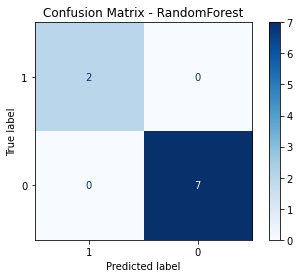

AUC (test): 1.0000
Recall (clase 0): 1.0000
Pipeline guardado en best_pipeline_RandomForest.pkl


In [20]:
# Código: detección automática de problema SMOTE y re-ejecución de CV + evaluación final


# ----------------------------
# Asegúrate de tener X_train, X_test, y_train, y_test definidos
# ----------------------------
X = df.drop(columns=['Target','Gait evaluation MDS-UPDRS','Gait_binary','ID','Estado'])
y = df['Target']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ----------------------------
# 1) Ver distribución clases
# ----------------------------

class_counts = y_train.value_counts()

minority_label = class_counts.idxmin()
majority_label = class_counts.idxmax()

n_minority_total = class_counts.min()

print("Distribución en TRAIN (total):")
print(class_counts.to_dict())
print(f"Etiqueta minoritaria: {minority_label} (n={n_minority_total})\n")

# ----------------------------
# 2) Cross Validation
# ----------------------------

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

minority_counts_in_train_folds = []

for train_idx, _ in cv.split(X_train, y_train):

    y_train_fold = y_train.iloc[train_idx]

    minority_counts_in_train_folds.append(
        int((y_train_fold == minority_label).sum())
    )

print("Minority samples in each training fold:", minority_counts_in_train_folds)

min_minority_in_train_fold = min(minority_counts_in_train_folds)

print("Min minority samples in any training fold:", min_minority_in_train_fold)

# ----------------------------
# 3) Elegir SMOTE o ROS
# ----------------------------

max_default_k = 5

k_possible = min(max_default_k, max(0, min_minority_in_train_fold - 1))

if k_possible >= 1:

    print(f"Usaremos SMOTE con k_neighbors = {k_possible}")

    sampler = SMOTE(k_neighbors=k_possible, random_state=42)

else:

    print("No hay suficientes muestras para SMOTE. Se usará RandomOverSampler.")

    sampler = RandomOverSampler(random_state=42)

# ----------------------------
# 4) Modelos
# ----------------------------

models = {

    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        base_estimator=DecisionTreeClassifier(max_depth=2),
        n_estimators=150,
        learning_rate=0.1,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
}

# ----------------------------
# 5) Cross Validation
# ----------------------------

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results_cv = {}

for name, model in models.items():

    pipe = ImbPipeline([

        ('sampler', sampler),
        ('clf', model)

    ])

    print(f"\nEjecutando CV para: {name} ...")

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results_cv[name] = {

        metric: scores[f'test_{metric}'].mean()
        for metric in scoring
    }

# ----------------------------
# 6) Resultados CV
# ----------------------------

res_df = pd.DataFrame(results_cv).T

res_df = res_df[['accuracy','precision','recall','f1','roc_auc']]

res_df = res_df.sort_values(by='recall', ascending=False)

print("\nResultados CV (promedios):")

print(res_df)

# ----------------------------
# 7) Elegir mejor modelo
# ----------------------------

best_model_name = res_df.index[0]

print(f"\nMejor modelo según recall en CV: {best_model_name}")

best_model = models[best_model_name]

best_pipeline = ImbPipeline([

    ('sampler', sampler),
    ('clf', best_model)

])

print("Entrenando el mejor pipeline en todo X_train...")

best_pipeline.fit(X_train, y_train)

# ----------------------------
# 8) Evaluación en test
# ----------------------------

y_pred = best_pipeline.predict(X_test)

if hasattr(best_pipeline.named_steps['clf'], "predict_proba"):

    y_proba = best_pipeline.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test, y_proba)

else:

    y_proba = None

    auc = np.nan

print("\nClassification report (TEST):")

print(classification_report(y_test, y_pred, digits=4))

# ----------------------------
# 9) Confusion matrix
# ----------------------------

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    cm,
    display_labels=[majority_label, minority_label]
)

disp.plot(cmap='Blues')

plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()

print(f"AUC (test): {auc:.4f}")

recall_minority = (
    ((y_test == minority_label) & (y_pred == minority_label)).sum()
    /
    (y_test == minority_label).sum()
)

print(f"Recall (clase {minority_label}): {recall_minority:.4f}")

# ----------------------------
# 10) Guardar modelo
# ----------------------------

import joblib

joblib.dump(best_pipeline, f"best_pipeline_{best_model_name}.pkl")

print(f"Pipeline guardado en best_pipeline_{best_model_name}.pkl")

In [21]:
model = best_pipeline.named_steps["clf"]

importances = model.feature_importances_

features = X_train.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

importance_df = importance_df.sort_values("Importance", ascending=False)


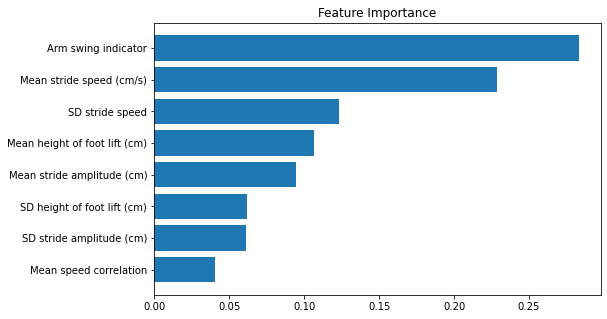

In [22]:
plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.show()

# RESULTADOS Y CONCLUSIONES

A partir del modelo Random Forest entrenado, se analizó la importancia relativa de cada variable para entender cuáles características de la marcha contribuyen más a la clasificación entre sujetos sanos y pacientes con Parkinson.

Los resultados muestran que las variables más influyentes son:
 - Arm swing indicator
 - Mean stride speed
 - SD stride speed

Esto indica que el balanceo de brazos y la velocidad del paso son factores clave para diferenciar entre sujetos sanos y pacientes, lo cual coincide con hallazgos clínicos sobre alteraciones de la marcha en la enfermedad de Parkinson.

Los resultados de validación cruzada muestran que Random Forest obtuvo el mejor desempeño general, con:

Accuracy: 0.94
Precision: 0.97
Recall: 0.96
F1-score: 0.96
ROC-AUC: 0.96

Por esta razón, Random Forest fue seleccionado como modelo final para el entrenamiento sobre el conjunto completo de entrenamiento.

Al evaluar el modelo en el conjunto de prueba, se obtuvo una exactitud del 100%.

Sin embargo, es importante considerar que el dataset es pequeño, lo cual puede generar un posible sobreajuste del modelo. Esto significa que el modelo puede estar aprendiendo patrones muy específicos del conjunto de entrenamiento.

A pesar de esto, los resultados sugieren que las características de la marcha utilizadas contienen información relevante para diferenciar entre sujetos sanos y pacientes con Parkinson.

En conclusión, el análisis exploratorio y el modelado predictivo muestran que variables relacionadas con la dinámica de la marcha, como la velocidad del paso y el balanceo de brazos, permiten identificar diferencias claras entre sujetos sanos y pacientes con Parkinson.

El modelo Random Forest demostró ser el enfoque más efectivo para esta tarea dentro de los algoritmos evaluados.

Futuras mejoras podrían incluir:
 - aumentar el tamaño del dataset
 - validar el modelo con nuevos pacientes
 - integrar más variables clínicas o sensoriales

Esto permitiría construir sistemas de apoyo al diagnóstico temprano basados en el análisis de la marcha.